In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset  
from torchvision import models, transforms
import pandas as pd
import cv2
import os

In [4]:
TRAIN_CSV = r"F:\DS-B3\MLinMedicine\practice 2\training_set_pixel_size_and_HC.csv"
TRAIN_IMG_DIR = r"F:\DS-B3\MLinMedicine\practice 2\training_set"  
MODEL_SAVE_PATH = r"F:\DS-B3\MLinMedicine\practice 2\fetal_hc_model.pth"

# Dataset definition 
class FetalDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        
        # Load image 
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Could not find image: {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            image = self.transform(image)
            
        # Get scalar inputs and targets
        pixel_size = torch.tensor([row['pixel size(mm)']], dtype=torch.float32)
        target = torch.tensor([row['head circumference (mm)']], dtype=torch.float32)
        
        return image, pixel_size, target


In [5]:
# Model architecture 
class RegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights='DEFAULT')
        num_ftrs = self.backbone.classifier[0].in_features
        self.backbone.classifier = nn.Identity() # Strip the default classifier

        self.regressor = nn.Sequential(
            nn.Linear(num_ftrs + 1, 128), # +1 is for the pixel_size scalar
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, img, pixel_size):
        img_features = self.backbone(img)
        # Combine image features with pixel size
        combined = torch.cat((img_features, pixel_size), dim=1)
        return self.regressor(combined)

# Training execution 
def train_model():
    # Setup Device
    device = torch.device("cpu") 
    
    # Image Transforms (Standard for pre-trained CNNs)
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Load Data
    train_dataset = FetalDataset(csv_file=TRAIN_CSV, img_dir=TRAIN_IMG_DIR, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

    # Initialize Model, Optimizer, and Loss (MAE)
    model = RegressionModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.L1Loss() # Mean Absolute Error (MAE) metric

    num_epochs = 10
    print(f"Starting Training on {len(train_dataset)} images...")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for images, pixel_sizes, targets in train_loader:
            images, pixel_sizes, targets = images.to(device), pixel_sizes.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(images, pixel_sizes)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_mae = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] - Training MAE: {avg_mae:.4f} mm")

    # Save the trained model
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print(f"Model saved to {MODEL_SAVE_PATH}")

if __name__ == "__main__":
    train_model()

Starting Training on 999 images...
Epoch [1/10] - Training MAE: 61.6541 mm
Epoch [2/10] - Training MAE: 27.0741 mm
Epoch [3/10] - Training MAE: 24.7537 mm
Epoch [4/10] - Training MAE: 25.0644 mm
Epoch [5/10] - Training MAE: 22.5836 mm
Epoch [6/10] - Training MAE: 17.9548 mm
Epoch [7/10] - Training MAE: 18.3606 mm
Epoch [8/10] - Training MAE: 19.1022 mm
Epoch [9/10] - Training MAE: 18.7393 mm
Epoch [10/10] - Training MAE: 17.0855 mm
Model saved to F:\DS-B3\MLinMedicine\practice 2\fetal_hc_model.pth


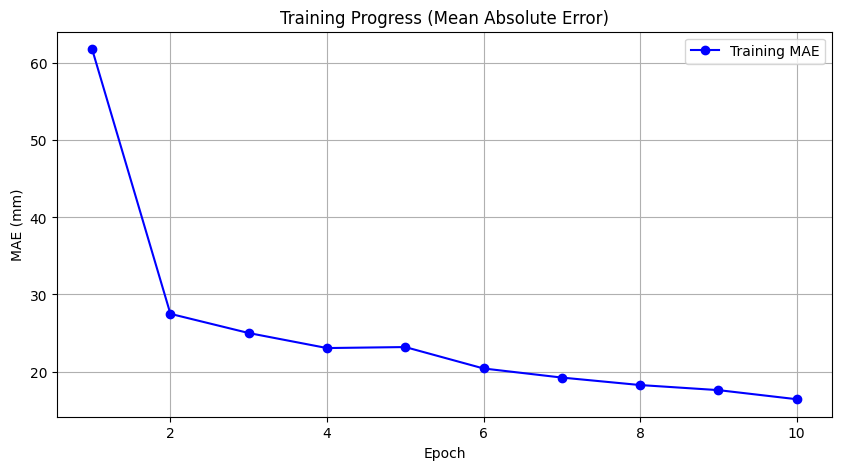

In [6]:
import matplotlib.pyplot as plt

# Create lists to store values during training
train_maes = [61.83, 27.49, 25.00, 23.05, 23.18, 20.40, 19.22, 18.25, 17.59, 16.41]
epochs = range(1, 11)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_maes, marker='o', color='b', label='Training MAE')
plt.title('Training Progress (Mean Absolute Error)')
plt.xlabel('Epoch')
plt.ylabel('MAE (mm)')
plt.grid(True)
plt.legend()
plt.show()